# 🔗 STACKING MULTIMODAL v1 — BASE: meta-modelo (LR/XGB) + interpretación por modalidad (CPU)
## TFM · Sistema de Apoyo a la Decisión Clínica Multimodal · Fusión tardía
### Universidad de Salamanca · Máster en Análisis Avanzado de Datos Multivariantes y Big Data

---

## 🆕 Qué cambia respecto al v1

En el **v1** este notebook **re-entrenaba** ECG y LABS por dentro (lo lento, ~2 h). En el **v2** cada notebook de
modalidad (01 CXR, 02 ECG, 03 LABS) **exporta ya su propio OOF/val/test**, así que aquí **solo se cargan los 3 CSV**.
Re-correr el stacking pasa a ser **casi instantáneo** (segundos). Lógica de fusión idéntica al v1.

## 🎯 Qué hace

Combina las predicciones de los **tres modelos por modalidad** (imagen, ECG, analíticas) con un **meta-modelo**
que aprende **cuánto pesa cada modalidad para cada enfermedad**. Se prueban **dos meta-modelos**: **Regresión
Logística** (L2) y **XGBoost** (poco profundo), y se comparan contra el **blending** (promedio) y contra el
**mejor modelo individual** (CXR).

## 🧱 Modelos base (mejor versión de cada modalidad, elegida por sus resultados reales)

| Modalidad | Versión usada | Macro AUC | De dónde salen las predicciones |
|---|---|---|---|
| **CXR** | **v5** (la mejor; v6.1/v6.2 salieron peor) | 0.809 | Se **cargan** `cxr_pred_*.csv` (notebook 01) |
| **ECG** | **v3.1** (ResNet1D base 48, señal 1250) | 0.629 | Se **cargan** `ecg_pred_*.csv` (notebook 02) |
| **LABS** | **blend v2.2** (XGB+LGB+LogReg+MLP) | ~0.69 | Se **cargan** `labs_pred_*.csv` (notebook 03) |

## ⚠️ Lo más importante: predicciones OUT-OF-FOLD (sin data leakage)

El meta-modelo NO puede entrenarse con predicciones de modelos que vieron esos datos. Por eso cada notebook exporta:
- Para **train** predicciones **out-of-fold (OOF)**: cada muestra la predice un modelo que **no la vio**.
- Para **test** los modelos base se reentrenan en **todo el train** y predicen test (test queda **100% limpio**).
- El rendimiento del meta-modelo se estima con **K-fold sobre las OOF** (no con el mismo train que las generó).

## 🧠 Entrada del meta-modelo

**18 probabilidades** (6 etiquetas × 3 modalidades, **calibradas**) **+ contexto clínico** (edad, sexo, raza, tipo y
lugar de ingreso, horas). El meta aprende, p. ej., que para Cardiomegaly el ECG/LABS aportan, y para Atelectasis manda la imagen.

## 🩻 Se respetan todas las reglas de las modalidades

Masking de NaN/−1 intacto · negativos derivados por exclusividad (No Finding) · desequilibrio por etiqueta · AUC-ROC macro.

## ⏱️ Coste (CPU): **segundos** (solo carga + meta-modelos ligeros). El coste pesado vive ahora en los notebooks 01/02/03.


In [1]:
# CELDA 1 · DEPENDENCIAS (v2 solo carga CSV + meta-modelos ligeros: no necesita torch/lightgbm)
import subprocess, sys
for pkg in ["xgboost","scikit-learn","pandas","numpy","matplotlib","seaborn"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"],check=True)
print("Dependencias instaladas.")

Dependencias instaladas.


In [2]:
# CELDA 2 · IMPORTS / SEMILLAS / CONSTANTES
import os, gc, json, time, copy, random, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve
import xgboost as xgb
warnings.filterwarnings("ignore")
SEED=42; random.seed(SEED); np.random.seed(SEED); DEVICE="cpu"

NB=Path.cwd()
BASE=Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR=BASE/"data_csv"/"clean"
TRAIN_CSV,VAL_CSV,TEST_CSV=CSV_DIR/"train_clean.csv",CSV_DIR/"val_clean.csv",CSV_DIR/"test_clean.csv"
# v2: las 3 modalidades exportan ya su OOF/val/test -> aquí SOLO se cargan los CSV (ver notebooks 01/02/03)
CXR_OOF =NB/"outputs_cxr_densenet121_v2"     # CXR  v5   -> cxr_pred_*.csv
ECG_OOF =NB/"outputs_ecg_resnet1d_v2"      # ECG  v3.1 -> ecg_pred_*.csv
LABS_OOF=NB/"outputs_labs_tabular_v2"      # LABS v2.2 -> labs_pred_*.csv
OUT=NB/"outputs_stacking_v1"; OUT.mkdir(parents=True,exist_ok=True)
FIG=OUT/"figuras"; FIG.mkdir(parents=True,exist_ok=True)

LABELS=["Atelectasis","Cardiomegaly","Edema","Lung Opacity","No Finding","Pleural Effusion"]
N_LABELS=len(LABELS); NO_FINDING="No Finding"
PATHOLOGY_LABELS=[l for l in LABELS if l!=NO_FINDING]; CORE_LABELS=["Cardiomegaly","Edema","Pleural Effusion"]
MODALITIES=["CXR","ECG","LABS"]
GENDER_MAP={0:0,1:1,"0":0,"1":1,"M":1,"F":0}
RACE_MAP={"UNKNOWN":0,"WHITE":1,"BLACK":2,"ASIAN":3,"HISPANIC_LATINO":4,"OTHER_KNOWN":0}
ADMISSION_MAP={"SCHEDULED":0,"EMERGENCY":1,"OBSERVATION":2,"URGENT":3}
ADM_LOC_MAP={"EMERGENCY_ROOM":0,"REFERRAL":1,"TRANSFER":2,"INTRA_HOSPITAL":3}; RACE_ONEHOT=5
print(f"Stacking v2 (solo carga OOF) · {DEVICE}")
print(f"dirs OOF -> CXR:{CXR_OOF.exists()} ECG:{ECG_OOF.exists()} LABS:{LABS_OOF.exists()}")

Stacking v2 (solo carga OOF) · cpu
dirs OOF -> CXR:True ECG:True LABS:True


In [3]:
# CELDA 3 · CARGA, OBJETIVOS (masking + negativos derivados) Y CONTEXTO
df_train=pd.read_csv(TRAIN_CSV,sep=";"); df_val=pd.read_csv(VAL_CSV,sep=";"); df_test=pd.read_csv(TEST_CSV,sep=";")
def build_targets(df,uncertainty_policy="zeros",derive=True):
    raw=df[LABELS].to_numpy(dtype=float); N=raw.shape[0]
    labels=np.zeros((N,N_LABELS),np.float32); mask=np.zeros((N,N_LABELS),np.float32)
    mask[~np.isnan(raw)]=1.0; labels[raw==1]=1.0
    unc=(raw==-1); labels[unc]=1.0 if uncertainty_policy=="ones" else 0.0
    nf=LABELS.index(NO_FINDING); pc=[j for j in range(N_LABELS) if j!=nf]
    if derive:
        nfp=(raw[:,nf]==1)
        for j in pc:
            f=nfp&np.isnan(raw[:,j]); labels[f,j]=0.0; mask[f,j]=1.0
        ap=(raw[:,pc]==1).any(1); fn=ap&np.isnan(raw[:,nf]); labels[fn,nf]=0.0; mask[fn,nf]=1.0
    return labels,mask
y_train,m_train=build_targets(df_train); y_val,m_val=build_targets(df_val); y_test,m_test=build_targets(df_test)
def build_context(df):
    N=len(df); cols=[]; names=[]
    AGEMIN,AGEMAX=float(df_train["age"].min()),float(df_train["age"].max())
    HMIN,HMAX=float(df_train["hours_adm_to_cxr"].min()),float(df_train["hours_adm_to_cxr"].max())
    cols.append(((df["age"].astype(float)-AGEMIN)/(AGEMAX-AGEMIN+1e-8)).to_numpy()[:,None]); names.append("Edad")
    cols.append(df["gender"].map(lambda v:float(GENDER_MAP.get(v,0))).to_numpy()[:,None]); names.append("Sexo")
    def oh(series,mp,pref):
        M=np.zeros((N,max(mp.values())+1),np.float32)
        for i,v in enumerate(series): M[i,mp.get(str(v).upper(),0)]=1.0
        return M,[f"{pref}={k}" for k,_ in sorted(mp.items(),key=lambda x:x[1])][:M.shape[1]]
    for col,mp,pref in [("race",RACE_MAP,"Raza"),("admission_type",ADMISSION_MAP,"Ingreso"),("admission_location",ADM_LOC_MAP,"Lugar")]:
        M,nm=oh(df[col],mp,pref); cols.append(M); names+=nm
    cols.append(((df["hours_adm_to_cxr"].astype(float)-HMIN)/(HMAX-HMIN+1e-8)).to_numpy()[:,None]); names.append("Horas")
    return np.hstack(cols).astype(np.float32),names
CTX_tr,CTX_NAMES=build_context(df_train); CTX_vl,_=build_context(df_val); CTX_te,_=build_context(df_test)
print(f"train={len(df_train)} val={len(df_val)} test={len(df_test)} · contexto={CTX_tr.shape[1]} dims")


train=10000 val=750 test=464 · contexto=16 dims


In [4]:
# CELDA 4 · MÉTRICAS
def multilabel_metrics(probs,labels,mask,thresholds=None):
    if thresholds is None: thresholds={l:0.5 for l in LABELS}
    res={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]; npos=int(yt.sum()); nneg=int((1-yt).sum())
        thr=thresholds.get(l,0.5); pred=(yp>=thr).astype(float)
        if npos>=2 and nneg>=2: auc=roc_auc_score(yt,yp); ap=average_precision_score(yt,yp)
        else: auc=ap=float("nan")
        tp=int(((pred==1)&(yt==1)).sum()); tn=int(((pred==0)&(yt==0)).sum()); fp=int(((pred==1)&(yt==0)).sum()); fn=int(((pred==0)&(yt==1)).sum())
        res[l]={"AUC":auc,"AP":ap,"F1":f1_score(yt,pred,zero_division=0),"sens":tp/max(tp+fn,1),"spec":tn/max(tn+fp,1),"n_pos":npos,"n_neg":nneg,"thr":thr,"TP":tp,"TN":tn,"FP":fp,"FN":fn}
    def mac(g):
        v=[res[l]["AUC"] for l in g if not np.isnan(res[l]["AUC"])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"]=mac(CORE_LABELS); res["macro_AUC_path"]=mac(PATHOLOGY_LABELS); return res
def best_thresholds_by_f1(probs,labels,mask,grid=None):
    if grid is None: grid=np.linspace(0.05,0.95,37)
    thr={}
    for j,l in enumerate(LABELS):
        s=mask[:,j]==1; yt=labels[s,j]; yp=probs[s,j]
        if yt.sum()<2: thr[l]=0.5; continue
        bf,bt=-1,0.5
        for t in grid:
            f=f1_score(yt,(yp>=t).astype(float),zero_division=0)
            if f>bf: bf,bt=f,t
        thr[l]=float(bt)
    return thr
def dyn_pos_weight(y,m,clip=10.0):
    w=np.ones(N_LABELS,np.float32)
    for j in range(N_LABELS):
        s=m[:,j]==1; pos=(y[s,j]==1).sum(); neg=(y[s,j]==0).sum(); w[j]=np.clip(neg/max(pos,1),1/clip,clip)
    return w
print("Métricas listas.")


Métricas listas.


In [5]:
# CELDA 5 · CXR — cargar predicciones OOF/val/test (mejor versión v5) y alinear por hadm_id
def load_cxr(csv):
    d=pd.read_csv(csv).set_index("hadm_id")
    cols=[f"cxr_{l.replace(' ','_')}_cal" for l in LABELS]
    return d[cols]
cxr_oof_df=load_cxr(CXR_OOF/"cxr_pred_oof_train.csv")
cxr_val_df=load_cxr(CXR_OOF/"cxr_pred_val.csv")
cxr_test_df=load_cxr(CXR_OOF/"cxr_pred_test.csv")
def align(df_idx, pred_df):
    out=pred_df.reindex(df_idx["hadm_id"].to_numpy())
    miss=out.isna().any(axis=1).sum()
    if miss>0: print(f"   ⚠ {miss} hadm_id sin predicción CXR (se rellenan con 0.5)"); out=out.fillna(0.5)
    return out.to_numpy(np.float32)
CXR_oof=align(df_train,cxr_oof_df); CXR_vl=align(df_val,cxr_val_df); CXR_te=align(df_test,cxr_test_df)
print(f"CXR cargado · OOF={CXR_oof.shape} val={CXR_vl.shape} test={CXR_te.shape}")
print("   CXR OOF macro (sanity):", round(multilabel_metrics(CXR_oof,y_train,m_train)["macro_AUC_path"],4))


CXR cargado · OOF=(10000, 6) val=(750, 6) test=(464, 6)
   CXR OOF macro (sanity): 0.7858


In [6]:
# CELDA 6 · LABS — cargar OOF/val/test exportados por el notebook 03 (blend v2.2). Sin re-entrenar.
def load_mod(csv, prefix):
    d=pd.read_csv(csv).set_index("hadm_id")
    cols=[f"{prefix}_{l.replace(' ','_')}_cal" for l in LABELS]   # probabilidades CALIBRADAS (mejores features de fusión)
    return d[cols]
LABS_oof=align(df_train, load_mod(LABS_OOF/"labs_pred_oof_train.csv","labs"))
LABS_vl =align(df_val,   load_mod(LABS_OOF/"labs_pred_val.csv","labs"))
LABS_te =align(df_test,  load_mod(LABS_OOF/"labs_pred_test.csv","labs"))
print(f"LABS cargado · OOF={LABS_oof.shape} val={LABS_vl.shape} test={LABS_te.shape}")
print("   LABS OOF macro (sanity):", round(multilabel_metrics(LABS_oof,y_train,m_train)["macro_AUC_path"],4))

LABS cargado · OOF=(10000, 6) val=(750, 6) test=(464, 6)
   LABS OOF macro (sanity): 0.6708


In [7]:
# CELDA 7 · ECG — cargar OOF/val/test exportados por el notebook 02 (ResNet1D v3.1). Sin re-entrenar.
ECG_oof=align(df_train, load_mod(ECG_OOF/"ecg_pred_oof_train.csv","ecg"))
ECG_vl =align(df_val,   load_mod(ECG_OOF/"ecg_pred_val.csv","ecg"))
ECG_te =align(df_test,  load_mod(ECG_OOF/"ecg_pred_test.csv","ecg"))
print(f"ECG cargado · OOF={ECG_oof.shape} val={ECG_vl.shape} test={ECG_te.shape}")
print("   ECG OOF macro (sanity):", round(multilabel_metrics(ECG_oof,y_train,m_train)["macro_AUC_path"],4))

ECG cargado · OOF=(10000, 6) val=(750, 6) test=(464, 6)
   ECG OOF macro (sanity): 0.5907


In [8]:
# CELDA 8 · ENSAMBLAR MATRIZ DEL META-MODELO (18 probas + contexto)
def meta_matrix(cxr,ecg,labs,ctx): return np.hstack([cxr,ecg,labs,ctx]).astype(np.float32)
Xmeta_oof=meta_matrix(CXR_oof,ECG_oof,LABS_oof,CTX_tr)
Xmeta_vl =meta_matrix(CXR_vl ,ECG_vl ,LABS_vl ,CTX_vl)
Xmeta_te =meta_matrix(CXR_te ,ECG_te ,LABS_te ,CTX_te)
PROB_NAMES=[f"{m}:{l}" for m in MODALITIES for l in LABELS]
META_NAMES=PROB_NAMES+CTX_NAMES
print(f"Meta-features: {Xmeta_oof.shape[1]} (18 probas + {len(CTX_NAMES)} contexto)")
# Guardar las predicciones base para reproducibilidad
for nm,arr,df in [("oof_train",[CXR_oof,ECG_oof,LABS_oof],df_train),("val",[CXR_vl,ECG_vl,LABS_vl],df_val),("test",[CXR_te,ECG_te,LABS_te],df_test)]:
    cols={"hadm_id":df["hadm_id"].to_numpy()}
    for mi,mod in enumerate(MODALITIES):
        for j,l in enumerate(LABELS): cols[f"{mod}_{l.replace(' ','_')}"]=arr[mi][:,j]
    pd.DataFrame(cols).to_csv(OUT/f"base_preds_{nm}.csv",index=False)
print("Predicciones base guardadas (base_preds_*.csv).")


Meta-features: 34 (18 probas + 16 contexto)
Predicciones base guardadas (base_preds_*.csv).


In [9]:
# CELDA 9 · META-MODELOS (LogReg L2 + XGBoost) y BASELINES, evaluados sin leakage
def meta_ovr(make,Xtr,ytr,mtr,Xva,scale=False):
    P=np.full((len(Xva),N_LABELS),0.5,np.float32); sc=None
    if scale: sc=StandardScaler().fit(Xtr); Xtr=sc.transform(Xtr); Xva=sc.transform(Xva)
    for j in range(N_LABELS):
        sel=mtr[:,j]==1; Xj=Xtr[sel]; yj=ytr[sel,j]
        if len(np.unique(yj))<2: P[:,j]=float(yj.mean()) if len(yj) else 0.5; continue
        clf=make(); clf.fit(Xj,yj); P[:,j]=clf.predict_proba(Xva)[:,1]
    return P
def make_lr(C=0.5): return LogisticRegression(C=C,class_weight="balanced",max_iter=2000,solver="lbfgs")
def make_xgbmeta(): return xgb.XGBClassifier(n_estimators=60,max_depth=2,learning_rate=0.08,subsample=0.8,colsample_bytree=0.8,reg_lambda=5.0,tree_method="hist",eval_metric="logloss",n_jobs=4,random_state=SEED)

# Estimación honesta por K-fold sobre las OOF (el meta nunca ve, en cada fold, lo que predice)
def meta_cv(make,scale,Xmeta,k=5):
    kf=KFold(k,shuffle=True,random_state=SEED); P=np.zeros((len(Xmeta),N_LABELS),np.float32)
    for tr,va in kf.split(np.arange(len(Xmeta))):
        P[va]=meta_ovr(make,Xmeta[tr],y_train[tr],m_train[tr],Xmeta[va],scale=scale)
    return P
# Tuning ligero de C para LogReg sobre la CV interna
bestC,bestv=0.5,-1
for C in [0.05,0.1,0.3,0.5,1.0,2.0]:
    p=meta_cv(lambda C=C: make_lr(C),True,Xmeta_oof); v=multilabel_metrics(p,y_train,m_train)["macro_AUC_path"]
    if v>bestv: bestv,bestC=v,C
print(f"Mejor C LogReg: {bestC} (CV macro={bestv:.4f})")
oof_LR =meta_cv(lambda: make_lr(bestC),True,Xmeta_oof)
oof_XGB=meta_cv(make_xgbmeta,False,Xmeta_oof)
# Baselines OOF: blending (promedio de modalidades) y mejor individual (CXR)
oof_BLEND=np.mean([CXR_oof,ECG_oof,LABS_oof],axis=0)
APPROACHES={"Stacking_LR":oof_LR,"Stacking_XGB":oof_XGB,"Blending":oof_BLEND,"CXR_solo":CXR_oof}
print("\nEstimación CV (sobre OOF):")
for k,p in APPROACHES.items():
    mm=multilabel_metrics(p,y_train,m_train); print(f"   {k:12s} macroP={mm['macro_AUC_path']:.4f} core={mm['macro_AUC_core']:.4f}")


Mejor C LogReg: 0.05 (CV macro=0.7882)

Estimación CV (sobre OOF):
   Stacking_LR  macroP=0.7882 core=0.8103
   Stacking_XGB macroP=0.7893 core=0.8113
   Blending     macroP=0.7657 core=0.7903
   CXR_solo     macroP=0.7858 core=0.8084


In [10]:
# CELDA 10 · ENTRENAR META FINAL Y EVALUAR EN TEST (limpio)
val_LR =meta_ovr(lambda: make_lr(bestC),Xmeta_oof,y_train,m_train,Xmeta_vl,scale=True)
test_LR=meta_ovr(lambda: make_lr(bestC),Xmeta_oof,y_train,m_train,Xmeta_te,scale=True)
val_XGB =meta_ovr(make_xgbmeta,Xmeta_oof,y_train,m_train,Xmeta_vl,scale=False)
test_XGB=meta_ovr(make_xgbmeta,Xmeta_oof,y_train,m_train,Xmeta_te,scale=False)
val_BLEND=np.mean([CXR_vl,ECG_vl,LABS_vl],axis=0); test_BLEND=np.mean([CXR_te,ECG_te,LABS_te],axis=0)
TEST={"Stacking_LR":(test_LR,val_LR),"Stacking_XGB":(test_XGB,val_XGB),"Blending":(test_BLEND,val_BLEND),"CXR_solo":(CXR_te,CXR_vl)}
print(f"{'Enfoque':13s} {'macroP':>7} {'macroC':>7} | "+" ".join(f"{l[:5]:>6}" for l in LABELS))
print("-"*86); TESTM={}; rows=[]
for k,(tp,vp) in TEST.items():
    thr=best_thresholds_by_f1(vp,y_val,m_val); mm=multilabel_metrics(tp,y_test,m_test,thresholds=thr); TESTM[k]=mm
    print(f"{k:13s} {mm['macro_AUC_path']:.4f} {mm['macro_AUC_core']:.4f} | "+" ".join(f"{mm[l]['AUC']:.3f}" if not np.isnan(mm[l]['AUC']) else '   -' for l in LABELS))
    rows.append({"enfoque":k,"macro_path":mm["macro_AUC_path"],"macro_core":mm["macro_AUC_core"],**{l:mm[l]["AUC"] for l in LABELS}})
pd.DataFrame(rows).to_csv(OUT/"comparativa_enfoques.csv",index=False)
BESTAP=max(TESTM,key=lambda k:TESTM[k]["macro_AUC_path"]); print(f"\n>>> Mejor enfoque en test: {BESTAP} (macroP={TESTM[BESTAP]['macro_AUC_path']:.4f})")
best_test=TEST[BESTAP][0]; best_thr=best_thresholds_by_f1(TEST[BESTAP][1],y_val,m_val)
json.dump({"best_approach":BESTAP,"bestC_LR":bestC,"test_metrics":{k:{"macro_path":TESTM[k]["macro_AUC_path"],"macro_core":TESTM[k]["macro_AUC_core"],"per_label":{l:TESTM[k][l] for l in LABELS}} for k in TESTM}},
          open(OUT/"summary_stacking.json","w",encoding="utf-8"),indent=2,default=str,ensure_ascii=False)
print("Guardados comparativa_enfoques.csv y summary_stacking.json")


Enfoque        macroP  macroC |  Atele  Cardi  Edema  Lung   No Fi  Pleur
--------------------------------------------------------------------------------------
Stacking_LR   0.7869 0.8156 | 0.729 0.748 0.840 0.759 0.768 0.858
Stacking_XGB  0.7875 0.8160 | 0.732 0.741 0.847 0.757 0.770 0.860
Blending      0.7738 0.7987 | 0.707 0.732 0.828 0.765 0.760 0.837
CXR_solo      0.7825 0.8135 | 0.715 0.749 0.836 0.757 0.764 0.856

>>> Mejor enfoque en test: Stacking_XGB (macroP=0.7875)
Guardados comparativa_enfoques.csv y summary_stacking.json


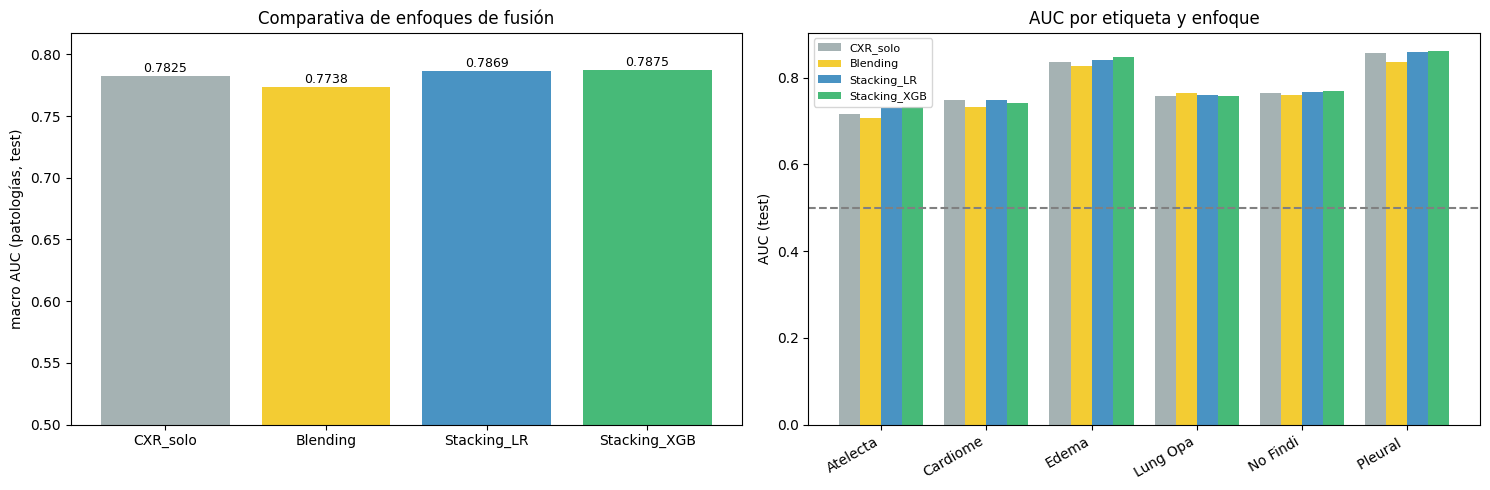

Figura guardada.


In [11]:
# CELDA 11 · GRÁFICA COMPARATIVA (barras macro + por etiqueta)
fig,axes=plt.subplots(1,2,figsize=(15,5))
order=["CXR_solo","Blending","Stacking_LR","Stacking_XGB"]; cols=["#95a5a6","#f1c40f","#2980b9","#27ae60"]
ax=axes[0]; vals=[TESTM[k]["macro_AUC_path"] for k in order]
ax.bar(order,vals,color=cols,alpha=0.85); ax.set_ylim(0.5,max(vals)+0.03); ax.set_ylabel("macro AUC (patologías, test)")
ax.set_title("Comparativa de enfoques de fusión")
for i,v in enumerate(vals): ax.text(i,v+0.003,f"{v:.4f}",ha="center",fontsize=9)
ax=axes[1]; x=np.arange(N_LABELS); wbar=0.2
for i,k in enumerate(order):
    ax.bar(x+(i-1.5)*wbar,[TESTM[k][l]["AUC"] for l in LABELS],wbar,label=k,color=cols[i],alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([l[:8] for l in LABELS],rotation=30,ha="right"); ax.axhline(0.5,color="gray",ls="--")
ax.set_ylabel("AUC (test)"); ax.set_title("AUC por etiqueta y enfoque"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"comparativa_enfoques.png",dpi=150,bbox_inches="tight"); plt.show()
print("Figura guardada.")


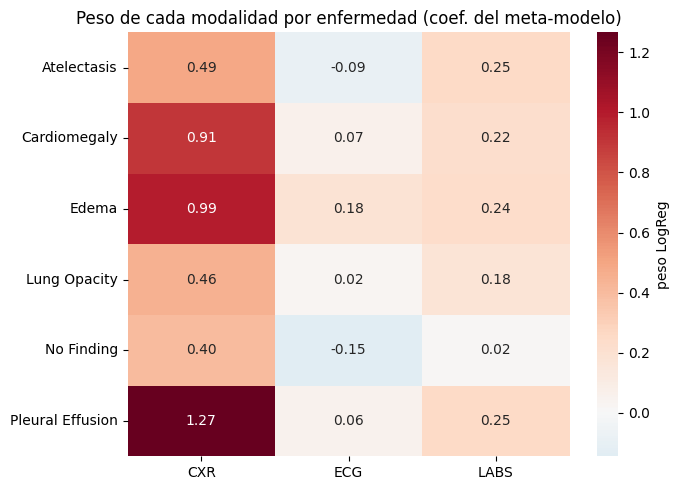

Modalidad dominante por enfermedad (según |peso|):
   Atelectasis        -> CXR (pesos: CXR=+0.49, ECG=-0.09, LABS=+0.25)
   Cardiomegaly       -> CXR (pesos: CXR=+0.91, ECG=+0.07, LABS=+0.22)
   Edema              -> CXR (pesos: CXR=+0.99, ECG=+0.18, LABS=+0.24)
   Lung Opacity       -> CXR (pesos: CXR=+0.46, ECG=+0.02, LABS=+0.18)
   No Finding         -> CXR (pesos: CXR=+0.40, ECG=-0.15, LABS=+0.02)
   Pleural Effusion   -> CXR (pesos: CXR=+1.27, ECG=+0.06, LABS=+0.25)


In [12]:
# CELDA 12 · INTERPRETACIÓN: ¿qué modalidad pesa en cada enfermedad? (coeficientes LogReg)
# Se entrena un LogReg por etiqueta SOLO sobre las 18 probabilidades (sin contexto) para leer pesos limpios.
sc=StandardScaler().fit(Xmeta_oof[:, :18]); Xp=sc.transform(Xmeta_oof[:, :18])
W=np.zeros((N_LABELS,3))  # peso agregado por modalidad y etiqueta
coef_full=np.zeros((N_LABELS,18))
for j,l in enumerate(LABELS):
    sel=m_train[:,j]==1; yj=y_train[sel,j]
    if len(np.unique(yj))<2: continue
    clf=make_lr(bestC).fit(Xp[sel],yj); co=clf.coef_[0]; coef_full[j]=co
    for mi in range(3): W[j,mi]=co[mi*N_LABELS+j]   # peso de la modalidad mi para SU misma etiqueta j
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(W,annot=True,fmt=".2f",cmap="RdBu_r",center=0,xticklabels=MODALITIES,yticklabels=LABELS,ax=ax,cbar_kws={"label":"peso LogReg"})
ax.set_title("Peso de cada modalidad por enfermedad (coef. del meta-modelo)")
plt.tight_layout(); plt.savefig(FIG/"pesos_modalidad_enfermedad.png",dpi=150,bbox_inches="tight"); plt.show()
print("Modalidad dominante por enfermedad (según |peso|):")
for j,l in enumerate(LABELS):
    mi=int(np.argmax(np.abs(W[j]))); print(f"   {l:18s} -> {MODALITIES[mi]} (pesos: "+", ".join(f'{MODALITIES[k]}={W[j,k]:+.2f}' for k in range(3))+")")


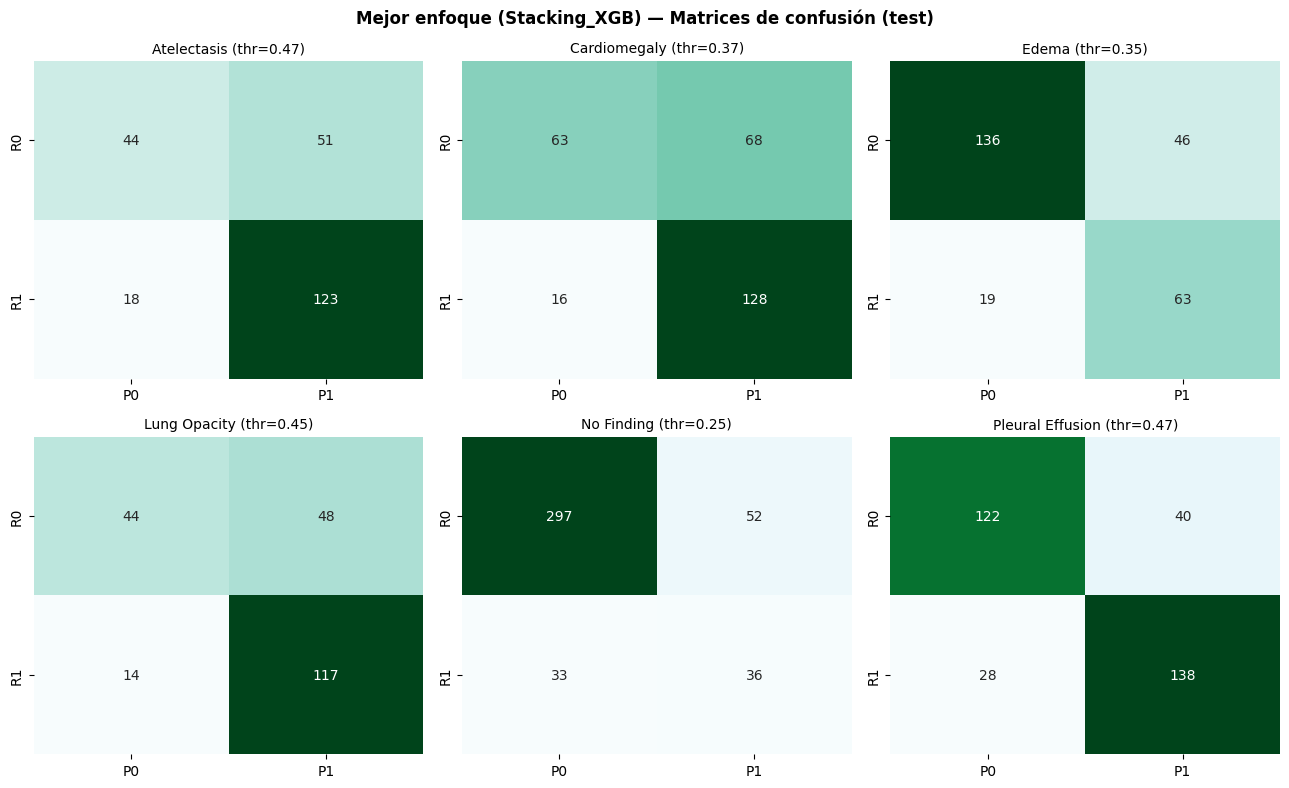

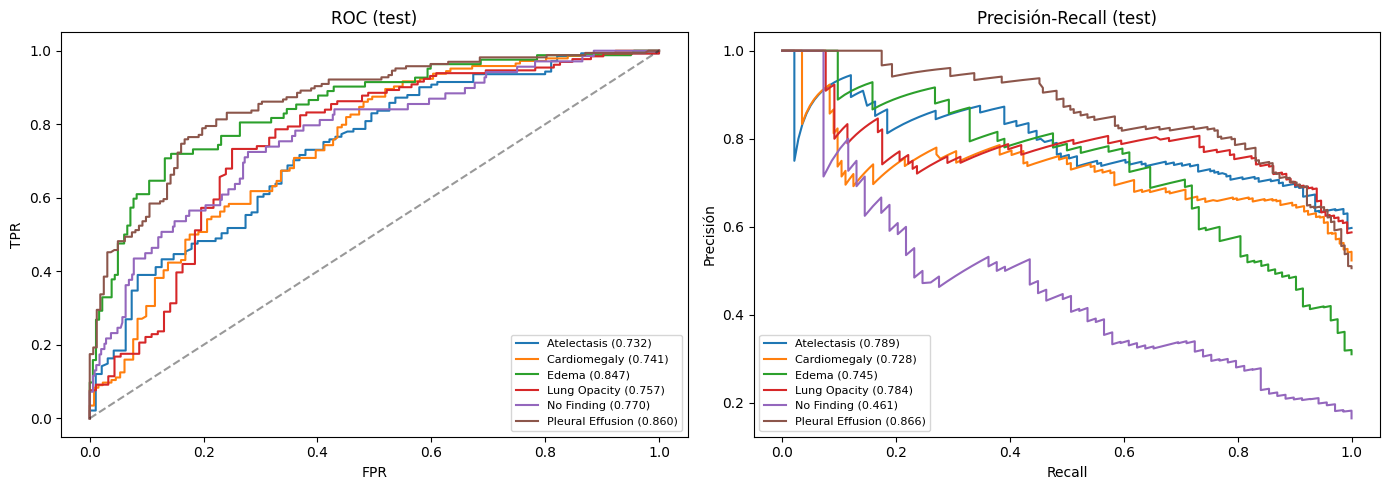

Figuras guardadas en c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\outputs_stacking_v1\figuras


In [13]:
# CELDA 13 · MATRICES DE CONFUSIÓN + ROC/PR del mejor enfoque (test)
fig,axes=plt.subplots(2,3,figsize=(13,8)); fig.suptitle(f"Mejor enfoque ({BESTAP}) — Matrices de confusión (test)",fontweight="bold")
for j,l in enumerate(LABELS):
    ax=axes[j//3,j%3]; s=m_test[:,j]==1; yt=y_test[s,j]; yp=(best_test[s,j]>=best_thr.get(l,0.5)).astype(int)
    if len(yt)==0: ax.axis("off"); continue
    cm=confusion_matrix(yt,yp,labels=[0,1]); sns.heatmap(cm,annot=True,fmt="d",cmap="BuGn",cbar=False,ax=ax,xticklabels=["P0","P1"],yticklabels=["R0","R1"]); ax.set_title(f"{l} (thr={best_thr.get(l,0.5):.2f})",fontsize=10)
plt.tight_layout(); plt.savefig(FIG/"confusion_mejor_enfoque.png",dpi=150,bbox_inches="tight"); plt.show()
fig,axes=plt.subplots(1,2,figsize=(14,5))
for j,l in enumerate(LABELS):
    s=m_test[:,j]==1; yt=y_test[s,j]; yp=best_test[s,j]
    if len(np.unique(yt))<2: continue
    fpr,tpr,_=roc_curve(yt,yp); axes[0].plot(fpr,tpr,label=f"{l} ({TESTM[BESTAP][l]['AUC']:.3f})")
    pr,rc,_=precision_recall_curve(yt,yp); axes[1].plot(rc,pr,label=f"{l} ({TESTM[BESTAP][l]['AP']:.3f})")
axes[0].plot([0,1],[0,1],"k--",alpha=0.4); axes[0].set_title("ROC (test)"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend(fontsize=8)
axes[1].set_title("Precisión-Recall (test)"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisión"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"roc_pr_mejor_enfoque.png",dpi=150,bbox_inches="tight"); plt.show()
print("Figuras guardadas en", FIG)


---
## ✅ Conclusión — Stacking multimodal v2

Fusiona las predicciones de **CXR (v5), ECG (v3.1) y LABS (blend v2.2)** con un **meta-modelo** que aprende el peso de
cada modalidad por enfermedad. A diferencia del v1, aquí las predicciones base se **cargan** de los CSV que exporta cada
notebook de modalidad (OOF/val/test), de modo que re-correr la fusión es **casi instantáneo**. Predicciones
**out-of-fold** (sin data leakage), test **limpio**, y comparación de **dos meta-modelos** (Regresión Logística L2 y
XGBoost) frente a **blending** y al **mejor modelo individual**.

**Entradas:** `outputs_cxr_densenet121_v2/cxr_pred_*.csv`, `outputs_ecg_resnet1d_v2/ecg_pred_*.csv`,
`outputs_labs_tabular_v2/labs_pred_*.csv`.
**Salidas (en `outputs_stacking_v1/`):** `comparativa_enfoques.csv`, `summary_stacking.json`, `base_preds_*.csv`, y
figuras (comparativa, pesos modalidad×enfermedad, matrices de confusión, ROC/PR).

**Interpretación clave:** el heatmap de pesos muestra **qué modalidad manda en cada hallazgo** (CXR domina; LABS aporta
en Edema/Derrame; ECG aporta algo en Cardiomegaly). La mejora del stacking sobre CXR en solitario suele ser **modesta
(≈0.01-0.03 macro)**, pero el valor metodológico es la **fusión multimodal rigurosa** y su comparación con el blending.